## Importação de biblioteca

In [298]:
from pathlib import Path
import pandas as pd
import numpy as np

from scipy.stats import shapiro, probplot

import seaborn as sns 
import matplotlib.pyplot as plt


## Carregamento de dados

In [299]:
path = Path(r'../data/raw/desafio_nps_fase_1.csv')
url = 'https://github.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/blob/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv'

In [300]:
df = pd.read_csv(path)

### Variaveis

In [301]:
#barplot
nps_map = {1: 'Detratores', 2: 'Passivo', 3: 'Promotores'}


cores_nps = {
    "Detratores": "#E74C3C", # Vermelho
    "Passivo": "#F1C40F",    # Amarelo
    "Promotores": "#27AE60"  # Verde
}

dicionario_colunas = {
    'complaints_count' :'numero de reclamações',
    'delivery_delay_days':'dias de atraso',
    'customer_service_contacts':'numero de contatos com atendimento',
    'resolution_time_days':'dias para resolução'
    
}

### Funções 

In [302]:
#Categorias 

def nps_class(df):
    if df['nps_score'] <= 6:
        return 'detractors'
    elif df['nps_score'] < 9:
        return 'passives'
    else:
        return 'promoter'

In [303]:
#Graficos

def gerar_barplot(df,x):
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(data=df.assign(nps_labels=df['nps_cat'].map(nps_map)), 
                  x=x, 
                  hue='nps_labels',
                  palette=cores_nps
                 )
    
    
    plt.title(f'Distribuição de Categorias NPS por {dicionario_colunas[x]}')
    plt.show()



def gerar_kdeplot(df,x):
    plt.figure(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.kdeplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        fill=True,      
        bw_adjust=2,
        common_norm=False, 

    )
    
    plt.title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    plt.xlabel(dicionario_colunas[x])
    plt.ylabel('Densidade de Clientes')
    plt.show()



def gerar_hisplot(df,x):
    plt.figure(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.histplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        multiple="stack",  # Empilha as categorias
        discrete=True,     # números inteiros
        shrink=0.8         # pedding
    )
    
    plt.title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    plt.xlabel(dicionario_colunas[x])
    plt.ylabel('Densidade de Clientes')
    plt.show()


def grafico_linhas_percentual(df,coluna):
    df_trend = pd.crosstab(df[coluna], df['nps_cat'], normalize='index') * 100
    
    df_trend.columns = nps_map.values() # ['Detratores', 'Passivo', 'Promotores']
    
    df_trend.plot(kind='line', marker='o', color=cores_nps, figsize=(10, 6))
    
    plt.title(f'Percentual de Categorias NPS conforme {dicionario_colunas[coluna]}')
    plt.ylabel('% de Clientes')
    plt.xlabel(f'{dicionario_colunas[coluna]}')
    plt.grid(alpha=0.3)
    plt.show()


def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste Shapiro-Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    # Plot histograma
    plt.figure(figsize=(6, 2))

    plt.subplot(1, 2, 1)
    plt.hist(data, bins=10)
    plt.title("Histograma")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot")

    plt.show()

    # Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f}  a  {ci_bootstrap[1]:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")


### Qualidade dos Dados

In [304]:
df.shape

(2500, 19)

In [305]:
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

In [306]:
df.isnull().sum().sum()

0

### Classificação de NPS

In [307]:
df['classificacao_nps'] = df.apply(nps_class,axis=1)
df['classificacao_nps'].value_counts().to_frame().assign(pct=df['classificacao_nps'].value_counts(1)*100)

,count,pct
classificacao_nps,,
detractors,1851,74.04
passives,539,21.56
promoter,110,4.40


In [308]:
#removendo da base colunas que nao serão necessárias
df_nps = df.drop(columns={'customer_id','csat_internal_score','classificacao_nps'})

**Categorizando as regiões com o one-hot encoder**

In [309]:
df_nps['customer_region'].unique()

array(['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste'],
      dtype=object)

In [310]:
region_cat = df_nps[['customer_region']]

try:
    from sklearn.preprocessing import OrdinalEncoder # apenas para gerar um ImportError se Scikit-Learn < 0.20
    from sklearn.preprocessing import OneHotEncoder
except ImportError:
    from future_encoders import OneHotEncoder # Scikit-Learn < 0.20

cat_encoder = OneHotEncoder()
region_cat_1hot = cat_encoder.fit_transform(region_cat)
region_cat_1hot

<2500x5 sparse matrix of type '<class 'numpy.float64'>'
	with 2500 stored elements in Compressed Sparse Row format>

In [311]:
df_1hot = pd.DataFrame(
    region_cat_1hot.toarray(), 
    columns=cat_encoder.get_feature_names_out(['customer_region']),
    index=df_nps.index
)

df_nps = pd.concat([df_nps, df_1hot], axis=1).drop('customer_region', axis=1)

In [312]:
df_nps.head(2)

,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,50001,139.73,4,39.35,4,2,2,55.53,...,0,4,6.9,0,3,0.0,1.0,0.0,0.0,0.0
1,20,1,50002,458.95,2,9.51,10,6,4,28.23,...,0,10,2.4,0,3,0.0,0.0,0.0,0.0,1.0


---

## Explorando o problema

**Pergunta principal**
> quais fatores operacionais realmente influenciam a satisfação do cliente ? <br>
como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da
aplicação da pesquisa de NPS?

### 1.Entendimento do negócio:

**Qual problema de negócio está sendo resolvido?** <br>
>Precisamos antecipar o resultado do NPS antes da pesquisa acontecer.

**Por que o NPS é importante para um e-commerce?**
> um NPS é importante por se tratar de uma métrica de satisfação dos clientes, a partir disso podemos avaliar a experiencia de nossos clientes tendo assim uma referencia da qualidade de nossos serviços, uma experiencia positiva pode afetar diretamente a receita através da recompra e fidelização dos clientes, custos por evitar retrabalho de logistica e/ou atendimentos especificos. uma alta NPS também é um sinal da reputação de nossa empresa o que ajuda a atrair novos clientes 

**Quais áreas poderiam se beneficiar desses insights?**

*podemos receber diversos benefios ao criar uma cultura voltada ao NPS* <br>
>- **Logistico:** analisar os atrasos e pensar em estratégias para diminuir o tempo de entrega <br>
>- **Atendimento ao cliente:** um numero de NPS maior indica menos contatos de resolução de problemas, acarretando indiretamente em menor tempo de resolução de problemas.  <br>
> - **Marketing:** ao identificarmos clientes promotores poderiamos por exemplo, criar programas de indicação de clientes com benefios, a experiencia positiva dos promotores pode ser uma alavanca importante para a divulgação dos nossos serviços. <br> 

### 1.1 impactos do NPS <br>

**Recompra** <br>
> recompra está diretamente relacionada aos promotores
> Churn está diretamente relacionado aos detratadores
<br>

**Boca a boca** <br>
> promotores podem gerar divulgação de nossos serviços de forma organica
> detratores podem gerar uma reputação negativa de nosso serviços impedindo de alcançarmos novos clientes
<br>


**Market share em e-commerce**<br>
> quanto melhor a experiencia de nossos clientes maior será o nosso market share, principalmente por se tratar de um e-commerce, esse setor especifico está a um clique de distancia de uma troca de fornecedores. 

**Quais indicadores de mercado poderiam complementar essa análise? Exemplos: benchmarks de NPS, SLA logístico, concorrência.**

### 2. Definição da Target:


**Qual variável representa a satisfação do cliente?** <br>
> nps_score
<br>

**Por que ela foi escolhida?** <br>
> é uma métrica recuperada de pesquisas, uma informação vinda dos próprios clientes é o indicador final de satisfação.
<br>

**Em que momento da jornada essa informação é coletada?** <br>
> ao fim da jornada de compras, no pós atendimento
<br>

**Existe algum risco de usar essa variável de forma inadequada?** <br>
> não temos a resposta de todos os clientes, normalmente teremos os maiores detratores ou promotores, além de não conseguir trazer toda a experiencia de nossos clientes é uma variavel simplificada

# 3. Análise Exploratória dos Dados (EDA)


● Que tipo de cliente tende a ter NPS mais alto ou mais baixo? <br>

#### **Quais fatores parecem mais críticos para a satisfação?**

faremos uma analise utilizando corr para identificar uma associação linear direta entre as notas de nps como um todo

In [313]:
correlacoes = df_nps.corr()['nps_score'].sort_values(ascending=True)
correlacoes

delivery_delay_days            -0.597260
complaints_count               -0.496800
customer_service_contacts      -0.350845
resolution_time_days           -0.191392
freight_value                  -0.041087
customer_region_Centro-Oeste   -0.032272
customer_age                   -0.009936
customer_tenure_months         -0.009711
customer_region_Sudeste        -0.000971
customer_region_Norte           0.000805
delivery_time_days              0.000925
customer_region_Nordeste        0.008415
items_quantity                  0.011468
order_id                        0.015162
customer_region_Sul             0.022975
payment_installments            0.023718
discount_value                  0.025104
delivery_attempts               0.027680
order_value                     0.036990
repeat_purchase_30d             0.570324
nps_score                       1.000000
Name: nps_score, dtype: float64

In [314]:
print('variaveis com maior probabilidade de afetar a satisfação')
correlacoes[abs(correlacoes) > 0.15]

variaveis com maior probabilidade de afetar a satisfação


delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

#### **O que mais gera detratores? <br>**

para responder essa pergunta primeiro vamos categorizar as nps <br>
> 1 detratores
 2 passivos
 3 promotores

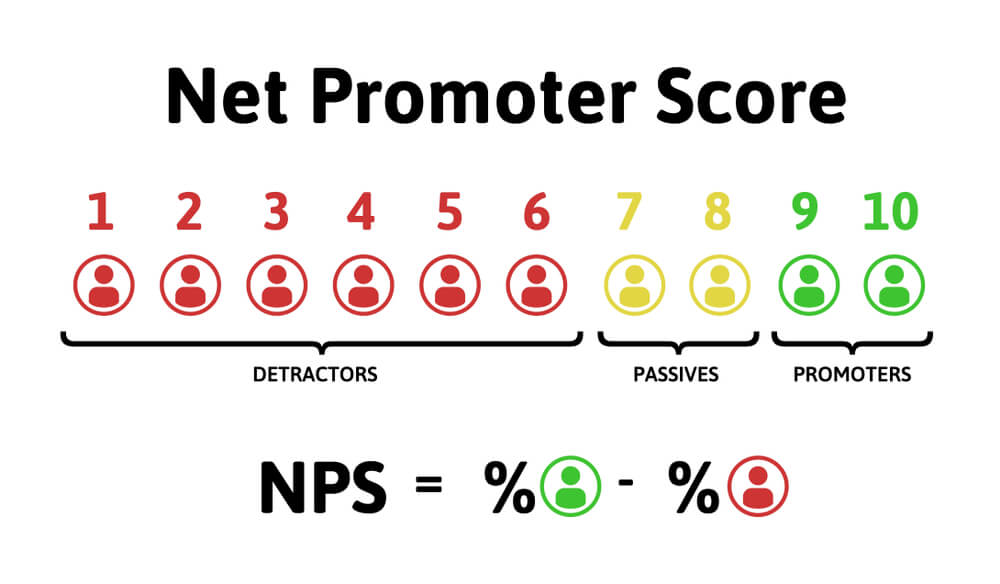

In [315]:
df_nps["nps_cat"] = pd.cut(df_nps["nps_score"],
                               bins=[-1,6 , 8, 10],
                               labels=[1, 2, 3])

In [316]:
print('nova associação, mas agora quanto relação das categoria do NPS')
nps_cat = df_nps.corr()['nps_cat'].sort_values(ascending=True)
nps_cat[:4]

nova associação, mas agora quanto relação das categoria do NPS


complaints_count            -0.443605
delivery_delay_days         -0.412236
customer_service_contacts   -0.246885
resolution_time_days        -0.158034
Name: nps_cat, dtype: float64

agora faremos uma analise utilizando as médias por grupos.<br>

In [317]:
#dataframe agrupado por categoria 
comparativo = df_nps.groupby('nps_cat',observed=False).mean()

o objetivo dessa analise é entender as maiores correlações entre os detratores  <br>
para isso iremos agrupar e faremos uma média de todos os dados, após isso iremos filtrar apenas os detratores [1]

In [318]:
perfil_detrator = comparativo.loc[1] / comparativo.median() 
perfil_detrator = perfil_detrator.sort_values(ascending=False)

print(perfil_detrator[:4])

delivery_delay_days          1.816590
complaints_count             1.547879
customer_service_contacts    1.500020
resolution_time_days         1.198866
dtype: float64


apenas para fim de estudos veremos as relações entre os promotores também

In [319]:
perfil_promotor = comparativo.loc[3] / comparativo.median() 
perfil_promotor = perfil_promotor.sort_values(ascending=False)

print(perfil_promotor[:4])

repeat_purchase_30d    26.352941
nps_score               1.319315
customer_region_Sul     1.211335
discount_value          1.068651
dtype: float64


#### <font size="5"> **Estudo de ruptura em contato do cliente** </font>

##### <font size="5">**Ruptura em numero de reclamações**</font>

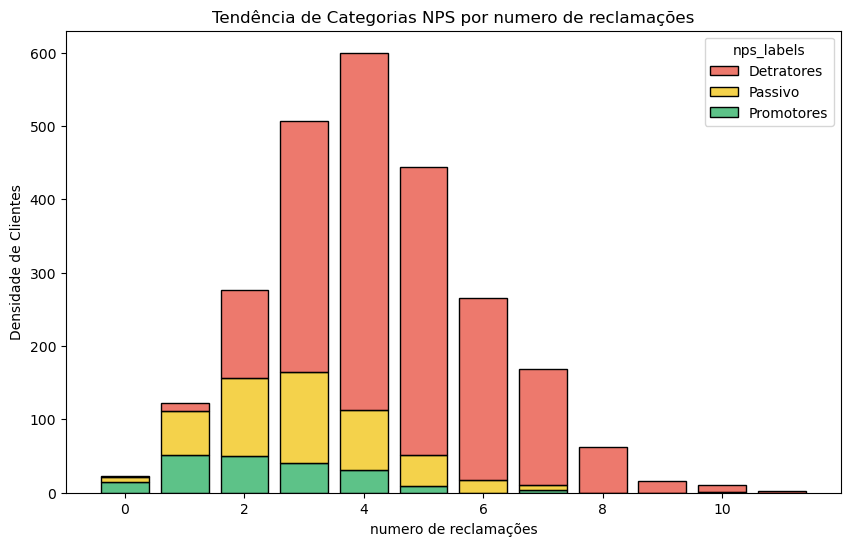

In [320]:
#histplot
gerar_hisplot(df_nps,'complaints_count')

> ao analisar a quantidade de reclamações é possivel notar uma tendencia de maior numero de detratores a partir da terceira reclamação 

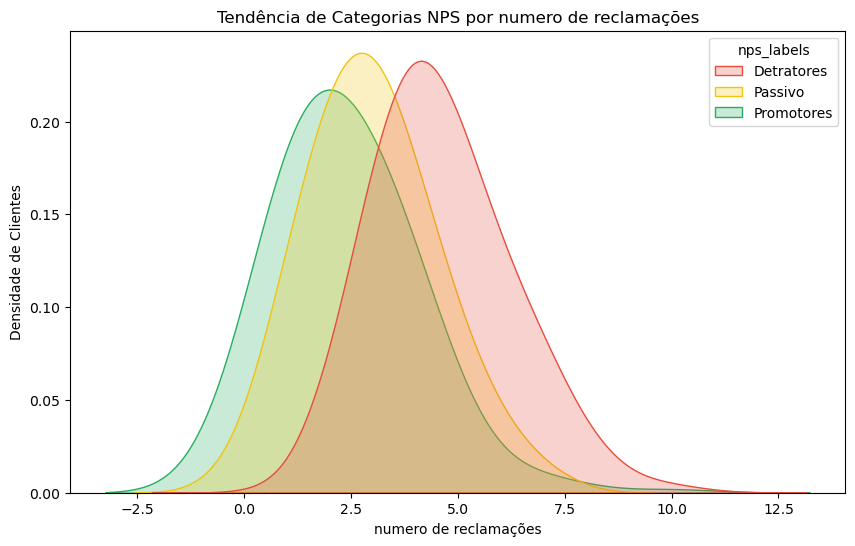

In [321]:
gerar_kdeplot(df_nps,'complaints_count')

> novamente identificamos um ponto de transição a partir de três reclamações,
aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser a quarta reclamação,
onde o numero de promotores passa a ser substancialmente menor que o numero de detratores
vamos fazer agora uma analise percentual de nps por numero de reclamações

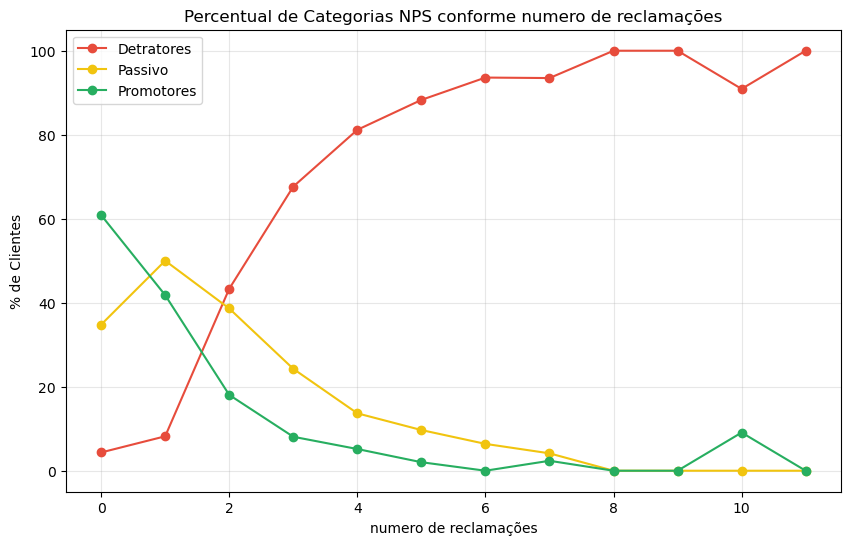

In [322]:
grafico_linhas_percentual(df_nps,'complaints_count')

> Em termos percentuais o numero de detratores supera os promotores a partir da segunda reclamação. 

##### <font size="5">**Ruptura em dias de atraso**</font>

faremos uma analise de contagem geral das categorias em relação ao dia de atrasos

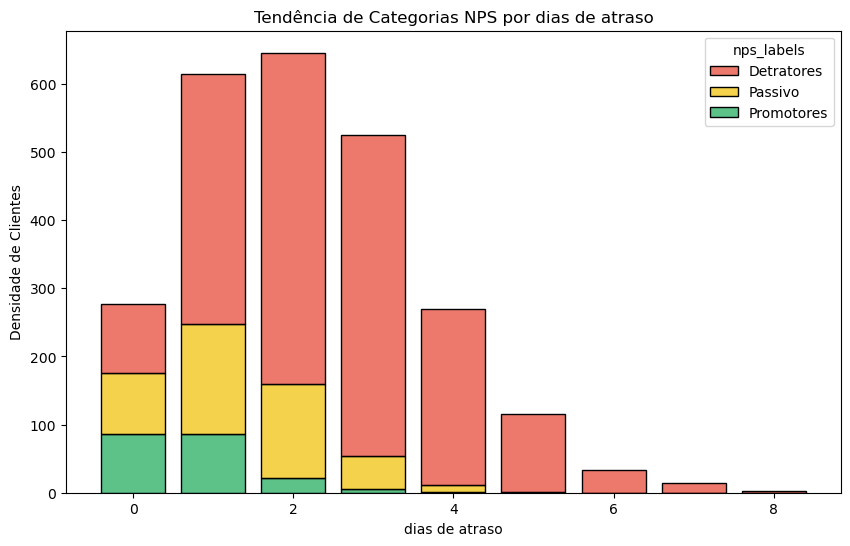

In [323]:
gerar_hisplot(df_nps,'delivery_delay_days')

podemos notar que a partir de 1 dia de atraso já temos um aumento substancial de detratores, e a partir do segundo dia de atraso o numero de promotores é quase nulo. 
agora vamos fazer uma analise de densidade 

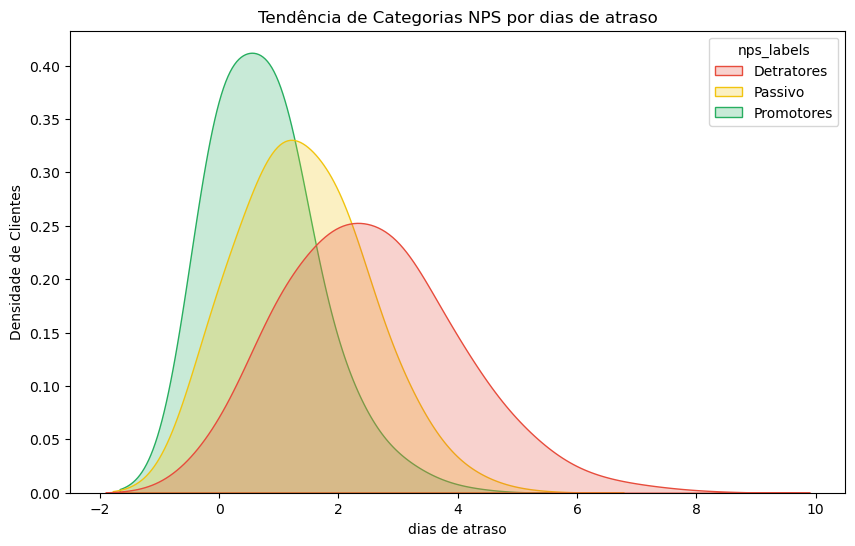

In [324]:
gerar_kdeplot(df_nps,'delivery_delay_days')

novamente identificamos um ponto de transição no segundo dia, aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser o terceiro dia, onde o numero de promotores passa a ser bem baixo
vamos fazer agora uma analise percentual de nps por dia de atraso

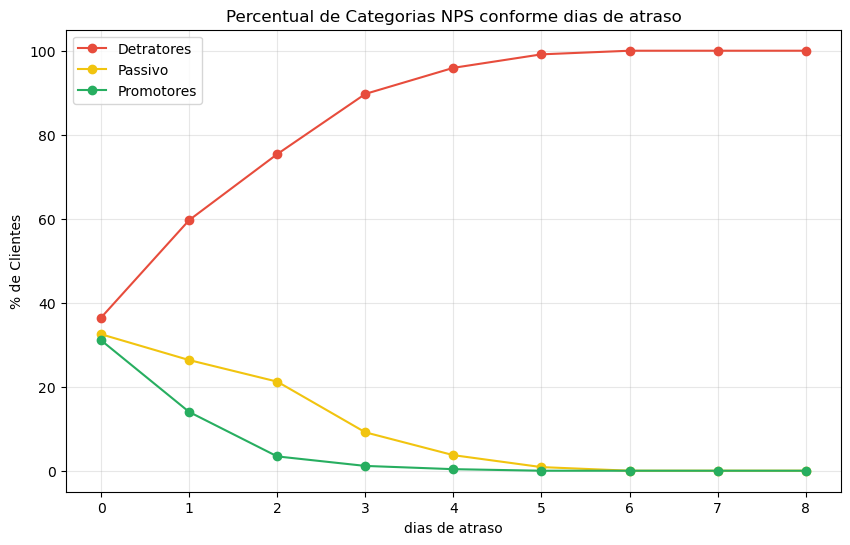

In [325]:
grafico_linhas_percentual(df_nps,'delivery_delay_days')

##### <font size="5">**Ruptura em numero de contatos**</font>

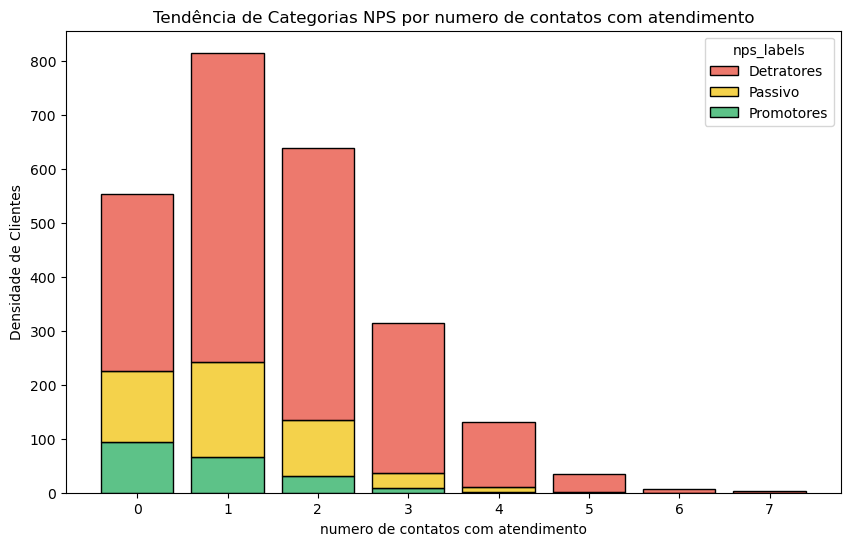

In [326]:
gerar_hisplot(df_nps,'customer_service_contacts')

Existe uma tendencia a detratores já no primeiro contato com nossa equipe de atendimento

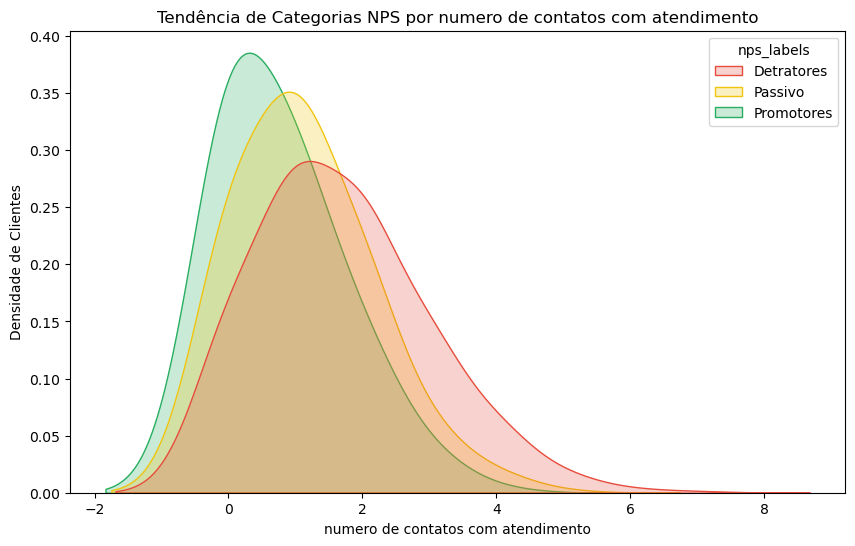

In [327]:
gerar_kdeplot(df_nps,'customer_service_contacts')

Podemos notar uma tendencia a promotores que entram em contato apenas uma vez com o SAC

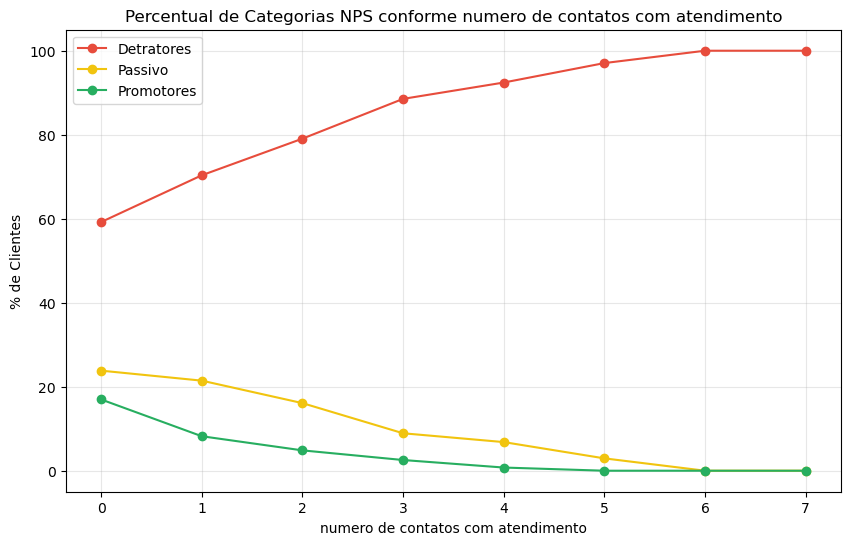

In [328]:
grafico_linhas_percentual(df_nps,'customer_service_contacts')

existe uma forte tendencia a detratores até mesmo antes de entrar em contato com atendimento. E conseguimos manter um percentual de passivos e promotores em torno de 40% se conseguirmos resolver o problema antes do segundo contato.

Vamos avaliar agora a ultima variavel com forte correlação

##### <font size="5">**Ruptura em em dias para a resolução de problemas**</font>

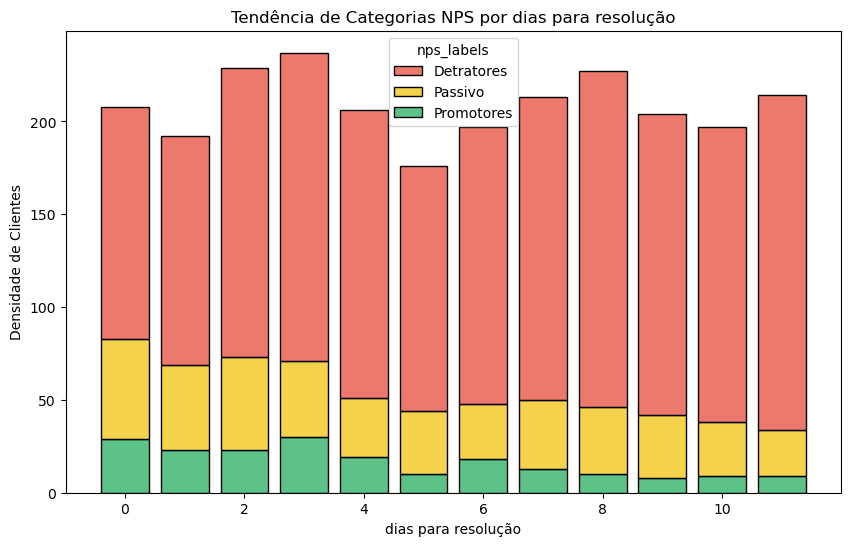

In [329]:
gerar_hisplot(df_nps,'resolution_time_days')

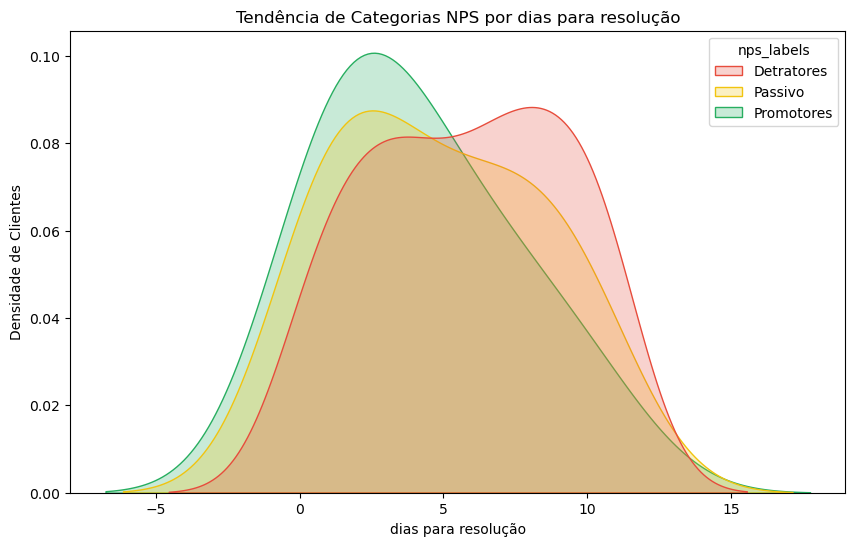

In [330]:
gerar_kdeplot(df_nps,'resolution_time_days')

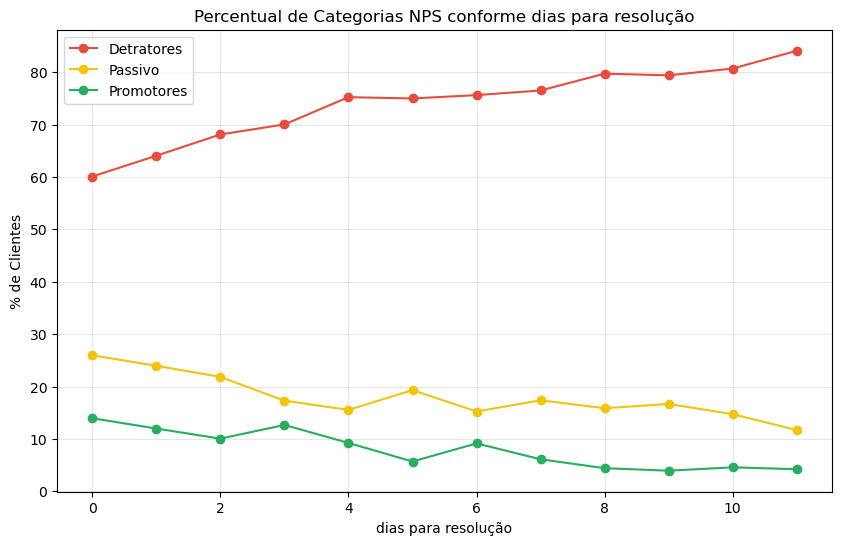

In [331]:
grafico_linhas_percentual(df_nps,'resolution_time_days')

Existe uma maior tendencia a se tornar detrator a partir de um atraso de 4 antes da resolução do problema   

#### <font size="6"> **Conclusão sobre os pontos de ruptura:** </font> <br>
**é possivel chegar a algumas hipóteses:** <br>
> a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores<br>
> a partir do segundo dia de atraso os clientes tem maior probabilidade de se tornarem detratores <br>
> a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores <br>
> a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator <br>

#### <font size="5"> **Estudo de hipoteses** </font>

In [332]:
from scipy.stats import mannwhitneyu

def teste_mann_w_u(grupo_1, grupo_2,h0="",alpha=0.05 ):
    stat, p_value = mannwhitneyu(grupo_1, grupo_2, alternative='two-sided')

    
    print(f"Estatística U: {stat}")
    print(f"p-valor: {p_value}")
    
    if p_value < alpha:
        print('Resultado: Há diferença simgnificativa.')
        print(f"Rejeitamos a hipótese nula (H0): {h0}")
        
    else:
        print('Resultado: Não há diferença significativa.')
        print(f"Não rejeitamos a hipótese nula (H0). {h0} ")

##### <font size="5">h1 = a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores</font>

In [333]:
hipotese_nula_reclamacoes = 'NPS se mantem igual com menos de três reclamações'
reclamacoes_h0 = df_nps[df_nps['complaints_count'] < 3]['nps_score']
reclamacoes_h1= df_nps[df_nps['complaints_count'] >= 3]['nps_score']

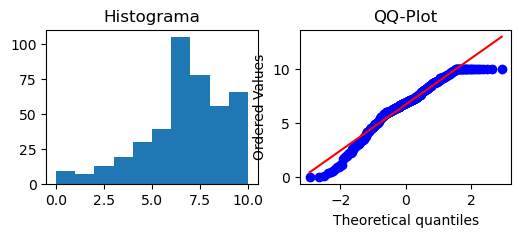

Média da amostra: 6.683
IC Bootstrap (95%): 6.466  a  6.892
p-valor Shapiro-Wilk: 0.0000 (não normal)


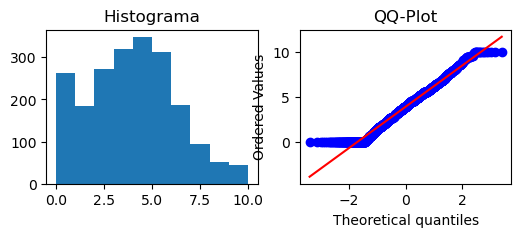

Média da amostra: 3.911
IC Bootstrap (95%): 3.805  a  4.010
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [334]:
analyze_distribution_and_ci(reclamacoes_h0)
analyze_distribution_and_ci(reclamacoes_h1)

In [335]:
teste_mann_w_u(reclamacoes_h0,reclamacoes_h1,hipotese_nula_reclamacoes)

Estatística U: 713910.5
p-valor: 2.558867076207088e-92
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com menos de três reclamações


##### <font size="5">h1 = a partir do 2º dia de atraso os clientes tem maior probabilidade de se tornarem detratores </font>

In [336]:
hipotese_nula_atraso = 'NPS se mantem igual com até dois dias de atraso'
atraso_h0 = df_nps[df_nps['delivery_delay_days'] < 3]['nps_score']
atraso_h1= df_nps[df_nps['delivery_delay_days'] >= 3]['nps_score']

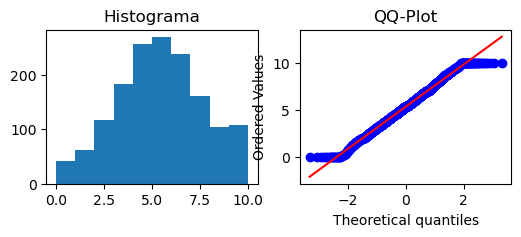

Média da amostra: 5.376
IC Bootstrap (95%): 5.268  a  5.488
p-valor Shapiro-Wilk: 0.0000 (não normal)


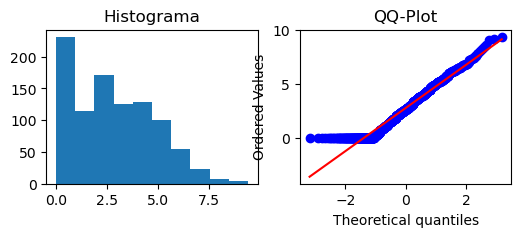

Média da amostra: 2.783
IC Bootstrap (95%): 2.653  a  2.915
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [337]:
analyze_distribution_and_ci(atraso_h0)
analyze_distribution_and_ci(atraso_h1)

In [338]:
teste_mann_w_u(atraso_h0,atraso_h1,hipotese_nula_atraso)

Estatística U: 1183034.0
p-valor: 1.224521170143194e-140
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com até dois dias de atraso


##### <font size="5">h1 = a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores</font>

In [339]:
hipotese_nula_contatos = 'Não há alteração no NPS com menos de dois contatos com o SAC'
contatos_h0 = df_nps[df_nps['customer_service_contacts'] < 2]['nps_score']
contatos_h1 = df_nps[df_nps['customer_service_contacts'] >= 2]['nps_score']

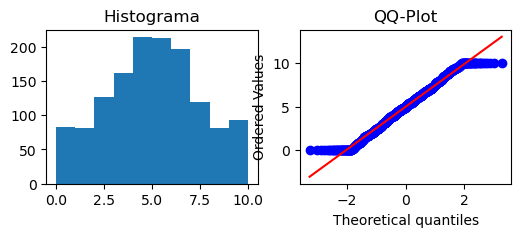

Média da amostra: 5.016
IC Bootstrap (95%): 4.884  a  5.147
p-valor Shapiro-Wilk: 0.0000 (não normal)


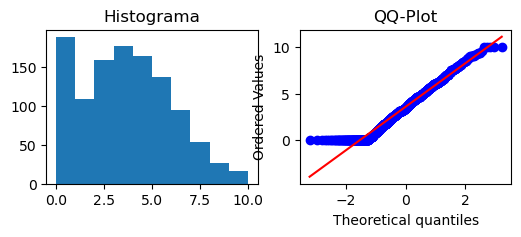

Média da amostra: 3.606
IC Bootstrap (95%): 3.469  a  3.743
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [340]:
analyze_distribution_and_ci(contatos_h0)
analyze_distribution_and_ci(contatos_h1)

In [341]:
teste_mann_w_u(contatos_h0,contatos_h1,hipotese_nula_contatos)

Estatística U: 1021819.5
p-valor: 2.677195218819886e-43
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois contatos com o SAC


##### <font size="5">h1 = a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator </font>

In [342]:
hipotese_nula_resolucao = 'Não há alteração no NPS com menos de dois resolucao de problemas'
resolucao_h0 = df_nps[df_nps['resolution_time_days'] < 3]['nps_score']
resolucao_h1 = df_nps[df_nps['resolution_time_days'] >= 3]['nps_score']

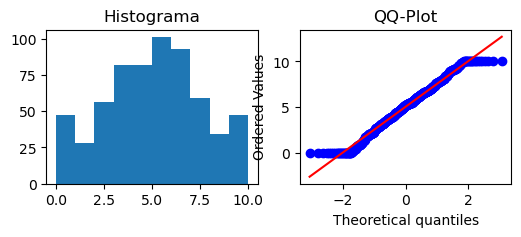

Média da amostra: 5.041
IC Bootstrap (95%): 4.842  a  5.236
p-valor Shapiro-Wilk: 0.0000 (não normal)


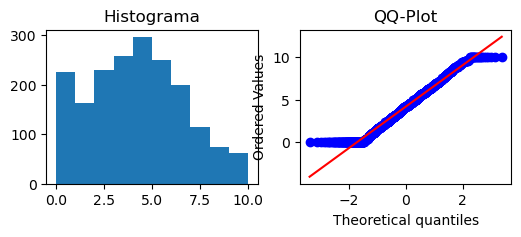

Média da amostra: 4.156
IC Bootstrap (95%): 4.045  a  4.268
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [343]:
analyze_distribution_and_ci(resolucao_h0)
analyze_distribution_and_ci(resolucao_h1)

In [344]:
teste_mann_w_u(resolucao_h0,resolucao_h1,hipotese_nula_resolucao)

Estatística U: 708017.5
p-valor: 2.217160622719586e-14
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois resolucao de problemas


#### <font size="6"> **Conclusão das hipoteses:** </font> <br>
**Nossas hipoteses foram validadas** <br>

Para mentermos o NPS alto precisamos evitar mais de duas reclamações, não atrasar mais de um dia, resolver os problemas no primeiro contato dos clientes e em até dois dias após o contato

### Analise de perfil de cliente

primeiro vamos tentar criar um perfil com base nas hipoteses que levantamos, criando um score ponderado(Heuristica) 

In [345]:
# Definindo os pesos com base na sua correlação
df_nps['risk_score'] = (
    (df_nps['complaints_count'] >= 3).astype(int) * 2 +          # Forte corr (-0.44)
    (df_nps['delivery_delay_days'] >= 2).astype(int) * 2 +       # Forte corr (-0.41)
    (df_nps['customer_service_contacts'] >= 2).astype(int) * 1 + # Média corr (-0.24)
    (df_nps['resolution_time_days'] >= 3).astype(int) * 1        # Baixa corr (-0.15)
)

# -1 a 1: Baixo (No máximo 1 problema leve)
# 2 a 3: Médio (Problema grave ou combinação de leves)
# 4 a 5: Alto (Combo de problemas graves)
# 6 : Critico - Pontuação máxima


df_nps['risk_level'] = pd.cut(
    df_nps['risk_score'],
    bins=[-1, 1, 3, 5, 6], 
    labels=['Baixo', 'Médio', 'Alto', 'Crítico']
)

In [346]:
# relação 
print(df_nps.groupby('risk_level', observed=False)['order_value'].sum())

risk_level
Baixo      103676.83
Médio      238193.88
Alto       507889.71
Crítico    235888.93
Name: order_value, dtype: float64


In [347]:
# Verificando a média de NPS por nível de risco
print(df_nps.groupby('risk_level', observed=False)['nps_score'].mean())

risk_level
Baixo      7.534199
Médio      5.798895
Alto       3.976500
Crítico    2.491897
Name: nps_score, dtype: float64


In [348]:
#Filtrar apenas as colunas que podem trazer alguma analise para o perfil dos nossos clientes

df_perfil = df_nps[['customer_age',
                    'customer_tenure_months',
                    'order_value',
                    'items_quantity',
                    'discount_value',
                    'payment_installments',
                    'delivery_time_days',
                    'delivery_delay_days',
                    'freight_value',
                    'delivery_attempts',
                    'customer_service_contacts',
                    'resolution_time_days',
                    'repeat_purchase_30d',
                    'complaints_count',
                    'customer_region_Centro-Oeste',
                    'customer_region_Nordeste',
                    'customer_region_Norte',
                    'customer_region_Sudeste',
                    'customer_region_Sul',
                    'risk_score',
                    'risk_level']
                ]

perfil = df_perfil.groupby('risk_level', observed=False).mean(numeric_only=True)

perfil.T

risk_level,Baixo,Médio,Alto,Crítico
customer_age,43.367965,43.769797,42.869822,44.180479
customer_tenure_months,60.229437,62.751381,60.630600,61.865562
order_value,448.817446,438.662762,429.323508,434.417919
items_quantity,3.320346,3.561694,3.477599,3.429098
discount_value,30.651775,32.294383,29.292781,27.797937
payment_installments,6.082251,6.103131,5.889265,6.121547
delivery_time_days,8.060606,7.804788,8.138631,7.968692
delivery_delay_days,0.510823,1.467772,2.479290,2.983425
freight_value,37.903030,37.950755,38.532857,37.928748
delivery_attempts,2.004329,2.012891,2.009298,1.990792


Faremos uma comparação de diferentes niveis de risco, utilizando o grupo de baixo risco como referencia (baseline= 1) <br>
Isso nos permitirá entender o quanto os problemas operacionais aumentam a medida que o risco do cliente cresce

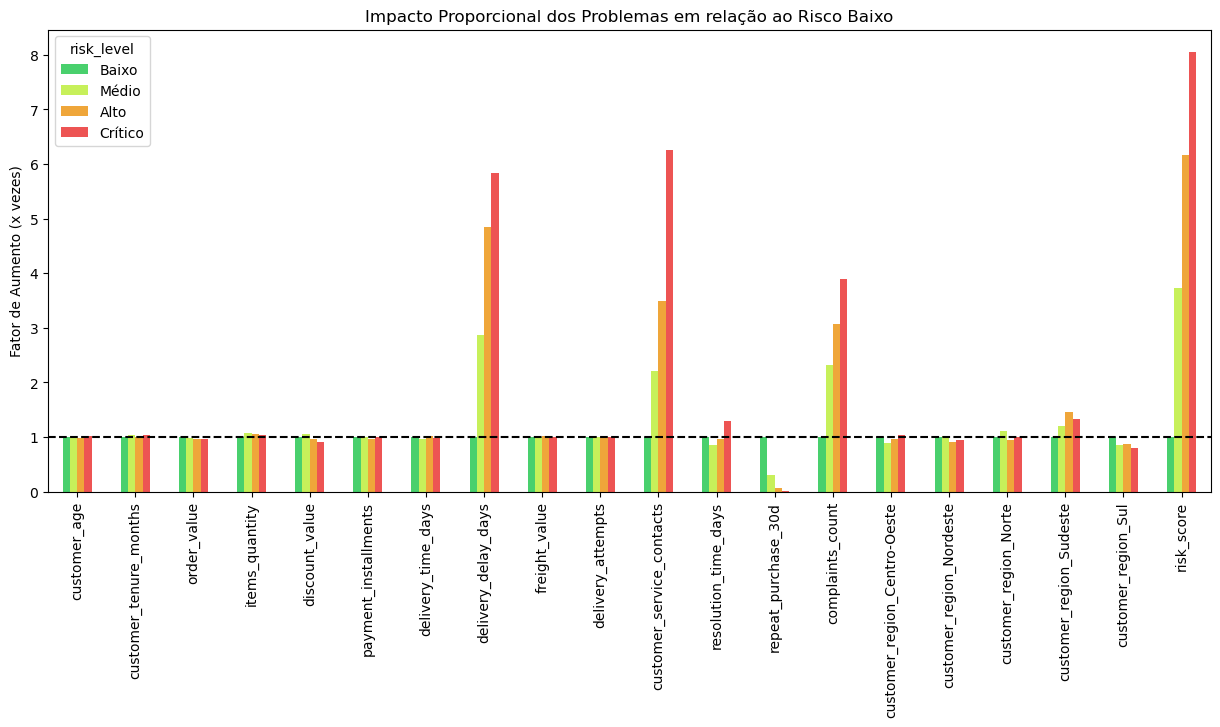

In [349]:
perfil_relativo = perfil / perfil.loc['Baixo']

ax = perfil_relativo.T.plot(kind='bar', figsize=(15, 6), color=minhas_cores)
plt.axhline(y=1, color='black', linestyle='--', label='Base (Risco Baixo)')
plt.title('Impacto Proporcional dos Problemas em relação ao Risco Baixo')
plt.ylabel('Fator de Aumento (x vezes)')
plt.show()

Clientes de risco crítico em média, apresentam cerca de 11 vezes mais dias de atraso do que clientes de baixo risco. <br>
Clientes de risco crítico em média, apresentam cerca de 10 vezes mais contatos com o SAC do que clientes de baixo risco. <br>
Clientes de risco crítico em média, reclamam 7 vezes do que clientes de baixo risco.<br>


O tempo de entrega não é um problema, uma vez que sempre se mantem estável, entretanto o atraso na entrega demonstra um crescimento exponencial no perfil de risco de nossos clientes, um dos grandes problemas é a quebra de promessa de entrega e não o prazo médio de entrega. 

o mesmo também pode se notar ao avaliar o contato com o SAC, uma não resolução gera maior perfil de risco

#### Analise por regiao

Foi possivel identificar um pequeno destaque na região sudeste faremos uma breve analise por região para identificar se essa relação é forte

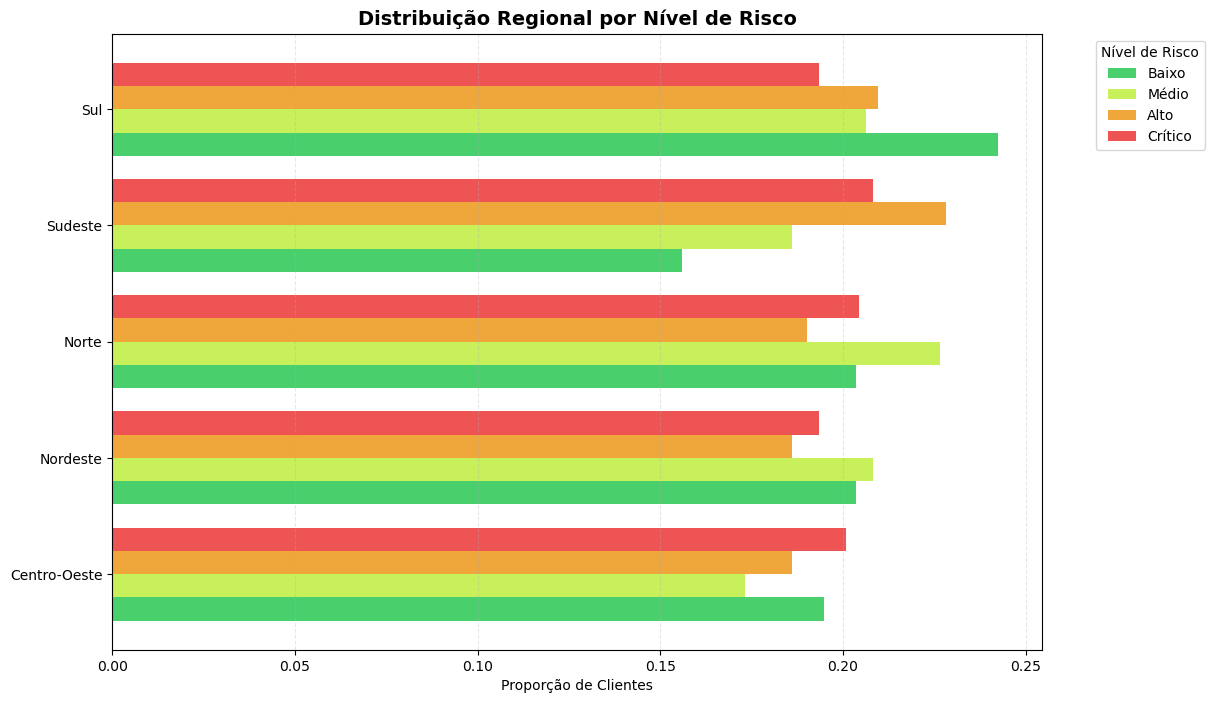

In [350]:
cols_regiao = ['customer_region_Centro-Oeste', 'customer_region_Nordeste','customer_region_Norte', 'customer_region_Sudeste', 'customer_region_Sul']
#Definindo cores do grafico
cores_temperatura = ['#49D06D', '#C7F05A', '#EFA63A', '#ED5453']
df_plot = perfil[cols_regiao].T
df_plot.index = [c.replace('customer_region_', '') for c in df_plot.index]


df_plot.plot(kind='barh', figsize=(12, 8), color=cores_temperatura, width=0.8)

plt.title('Distribuição Regional por Nível de Risco', fontsize=14, fontweight='bold')
plt.xlabel('Proporção de Clientes')
plt.legend(title='Nível de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

é possivel verificar que a região sul possui acumulo de perfil de baixo risco, talvez identificado por um menor atraso na região.<br>
também é possivel notar um maior nivel de risco na região sudeste <br>
Mas não foi visto o perfil de região como algo substancial para o nosso perfil de risco <br>
de qualquer forma, acho que podemos posteriormente estudar se existe essa relação

### validação de perfis

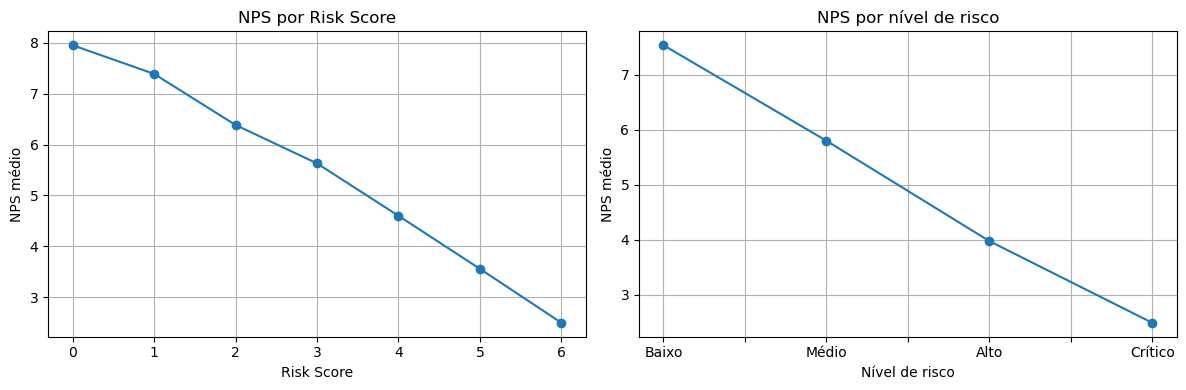

In [351]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Gráfico 1 - contínuo
df_nps.groupby('risk_score',observed=False)['nps_score'].mean().plot(
    marker='o', ax=axes[0]
)
axes[0].set_title('NPS por Risk Score')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('NPS médio')
axes[0].grid()

# Gráfico 2 - categórico
df_nps.groupby('risk_level',observed=False)['nps_score'].mean().plot(
    marker='o', 
    ax=axes[1]
)
axes[1].set_title('NPS por nível de risco')
axes[1].set_xlabel('Nível de risco')
axes[1].set_ylabel('NPS médio')
axes[1].grid()

plt.tight_layout()
plt.show()

Identificação de relação direta do risk_score com o nps_score, categoricamente e quantitativamente

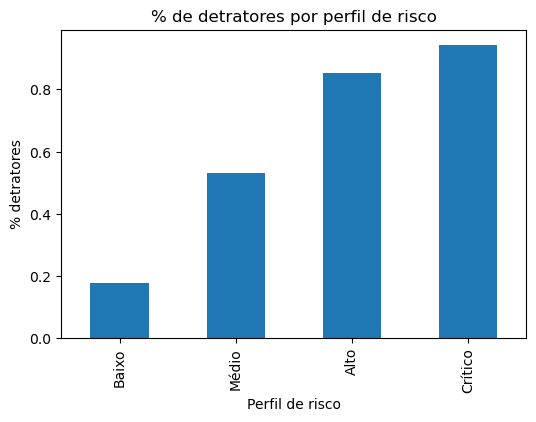

In [275]:
df_nps['is_detrator'] = (df_nps['nps_cat'] == 1)

plt.figure(figsize=(6,4))
df_nps.groupby('risk_level',observed=False)['is_detrator'].mean().plot(kind='bar')
plt.title('% de detratores por perfil de risco')
plt.ylabel('% detratores')
plt.xlabel('Perfil de risco')
plt.show()

é possivel visualizar um acumulo de percentual de detratores, conforme o risco se eleva 

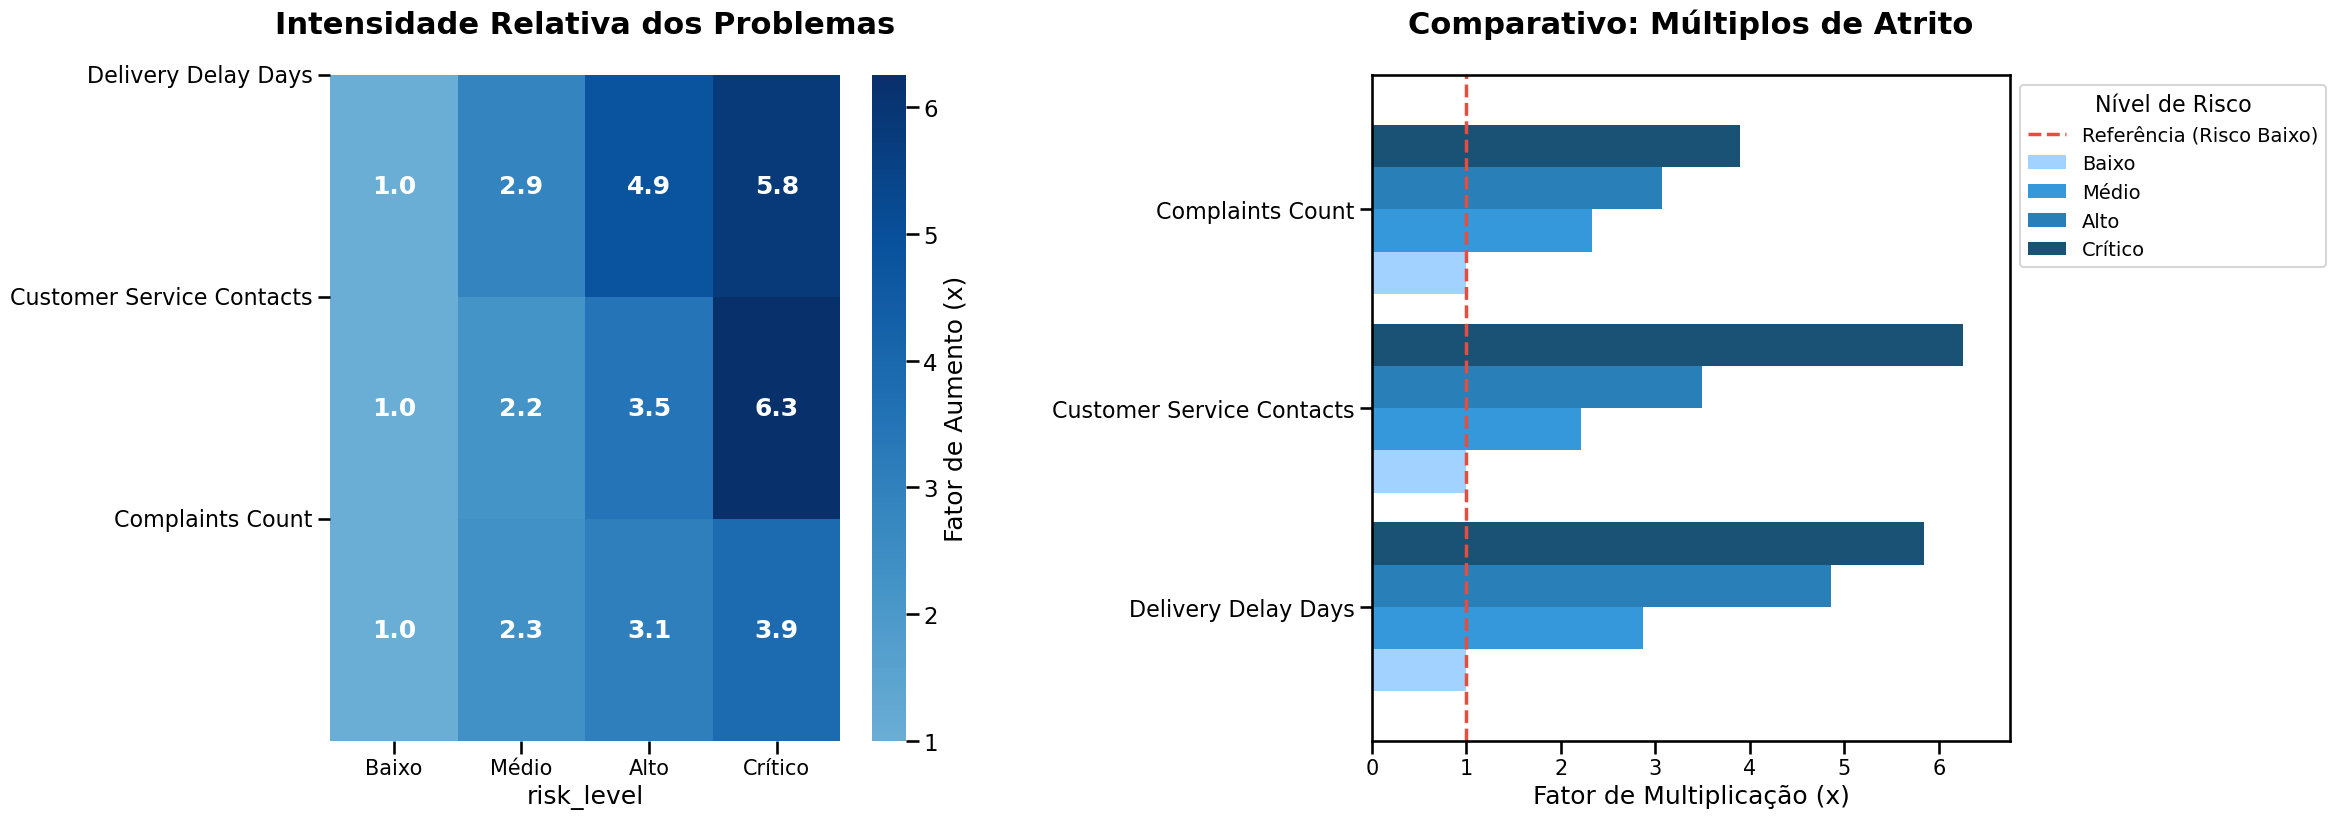

In [382]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk") 
paleta_cores = ['#A2D2FF', '#3498DB', '#2980B9', '#1A5276']
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# ------ HEATMAP 
sns.heatmap(perfil_rel[cols].T, annot=True, fmt=".1f", cmap='Blues', 
            center=1, ax=axes[0], 
            annot_kws={"size": 18, "weight": "bold"}, 
            cbar_kws={'label': 'Fator de Aumento (x)'})

axes[0].set_title('Intensidade Relativa dos Problemas', fontsize=22, pad=30, fontweight='bold')

#------ BARRAS HORIZONTAIS
perfil_rel[cols].T.plot(kind='barh', ax=axes[1], color=paleta_cores, width=0.85)

axes[1].axvline(1, color='#E74C3C', linestyle='--', linewidth=2.5, label='Referência (Risco Baixo)')
axes[1].set_title('Comparativo: Múltiplos de Atrito', fontsize=22, pad=30, fontweight='bold')
axes[1].set_xlabel('Fator de Multiplicação (x)', fontsize=18)
axes[1].legend(title='Nível de Risco', title_fontsize='16', fontsize='14', bbox_to_anchor=(1, 1))

# #------ AJUSTES DE ESCALA E LEGIBILIDADE
labels_limpos = [c.replace('_', ' ').title() for c in cols]

for ax in axes:
    ax.set_yticks(range(len(labels_limpos)))
    ax.set_yticklabels(labels_limpos, fontsize=16)
    
    ax.tick_params(axis='x', labelsize=15)
    ax.set_ylabel('', fontsize=0)

# Sincronizando os eixos 
axes[1].set_xlim(0, perfil_rel[cols].max().max() + 0.5)

plt.tight_layout(pad=4.0)
plt.show()

Por fim uma visualização da proporção dos problemas x nivel de risco em uma escala maior 

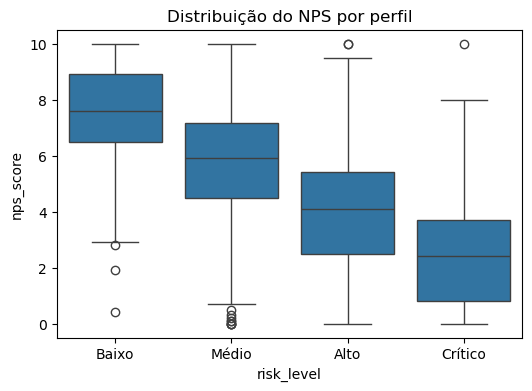

In [267]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='risk_level', y='nps_score', data=df_nps)
plt.title('Distribuição do NPS por perfil')
plt.show()

Analise da distribuição de NPS por perfil. <br>
perfil de baixo risco tende a estar próximo a 8 <br>
médio próximo a 6<br>
Alto próximo a 4 <br>
e critico próximo a 2

In [ ]:
# MODELO DE REGRESSAO CLASSIFICANDO DA FORMA COMO QUISER

### 4. Como forma de preparação para as próximas fases do curso, este desafio propõe uma reflexão prática sobre como a Ciência de Dados pode ser utilizada para antecipar a satisfação do cliente.